In [43]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [44]:
from pathlib import Path
import sys

working_directory = Path.cwd().resolve()
PROJECT_ROOT = next(
    (path for path in (working_directory, *working_directory.parents)
     if (path / "pyproject.toml").is_file() and (path / "src").is_dir()),
    None,
)
if PROJECT_ROOT is None:
    raise RuntimeError("Open this notebook from within the project directory.")
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

In [45]:
from src.data.loader import load_dataset

In [46]:
BENCHMARK_CONFIG = PROJECT_ROOT / "configs" / "benchmark.yaml"
OUTPUT_PATH = PROJECT_ROOT / "configs" / "benchmark_targets.yaml"

print(BENCHMARK_CONFIG.relative_to(PROJECT_ROOT).as_posix())
print(OUTPUT_PATH.relative_to(PROJECT_ROOT).as_posix())

configs/benchmark.yaml
configs/benchmark_targets.yaml


In [47]:
import yaml

from src.data.loader import load_dataset
from src.data.targets import select_benchmark_targets

In [48]:
with open(BENCHMARK_CONFIG, "r", encoding="utf-8") as file:
    config = yaml.safe_load(file)["benchmark"]

In [49]:
config["datasets"]

['ETTh1', 'Weather', 'Electricity', 'Traffic', 'Exchange', 'Solar']

In [50]:
def loading(loaded_dataset):
    display(loaded_dataset.values.head())
    
    print()
    
    display(loaded_dataset.values.describe())
    
    print()
    
    print(loaded_dataset.timestamps[:10])    
    print(loaded_dataset.timestamps.to_series().diff().value_counts().head())
    
    print()
    
    context = 512
    horizon = 192

    required_length = context + horizon

    print("Available:", loaded_dataset.n_observations)
    print("Required:", required_length)
    print(f"Valid: {loaded_dataset.n_observations >= required_length}")
    
    import matplotlib.pyplot as plt
    target = loaded_dataset.primary_target or loaded_dataset.target_columns[0]
    loaded_dataset.values[target].iloc[:1000].plot(figsize=(14, 5))
    plt.title(f"{loaded_dataset.name} - {target}", fontweight='bold')
    plt.xlabel('Observation')
    plt.ylabel(target)
    plt.grid(True, alpha=0.65, linestyle='--')
    plt.show()

### **ETTh1**

,HUFL,HULL,MUFL,MULL,LUFL,LULL,OT
0,5.827,2.009,1.599,0.462,4.203,1.340,30.531000
1,5.693,2.076,1.492,0.426,4.142,1.371,27.787001
2,5.157,1.741,1.279,0.355,3.777,1.218,27.787001
3,5.090,1.942,1.279,0.391,3.807,1.279,25.044001
4,5.358,1.942,1.492,0.462,3.868,1.279,21.948000


,HUFL,HULL,MUFL,MULL,LUFL,LULL,OT
count,17420.000000,17420.000000,17420.000000,17420.000000,17420.000000,17420.000000,17420.000000
mean,7.375141,2.242242,4.300239,0.881568,3.066062,0.856932,13.324672
std,7.067744,2.042342,6.826978,1.809293,1.164506,0.599552,8.566946
min,-22.705999,-4.756000,-25.087999,-5.934000,-1.188000,-1.371000,-4.080000
25%,5.827000,0.737000,3.296000,-0.284000,2.315000,0.670000,6.964000
50%,8.774000,2.210000,5.970000,0.959000,2.833000,0.975000,11.396000
75%,11.788000,3.684000,8.635000,2.203000,3.625000,1.218000,18.079000
max,23.643999,10.114000,17.341000,7.747000,8.498000,3.046000,46.007000



DatetimeIndex(['2016-07-01 00:00:00', '2016-07-01 01:00:00',
               '2016-07-01 02:00:00', '2016-07-01 03:00:00',
               '2016-07-01 04:00:00', '2016-07-01 05:00:00',
               '2016-07-01 06:00:00', '2016-07-01 07:00:00',
               '2016-07-01 08:00:00', '2016-07-01 09:00:00'],
              dtype='datetime64[ns]', name='date', freq=None)
date
0 days 01:00:00    17419
Name: count, dtype: int64

Available: 17420
Required: 704
Valid: True


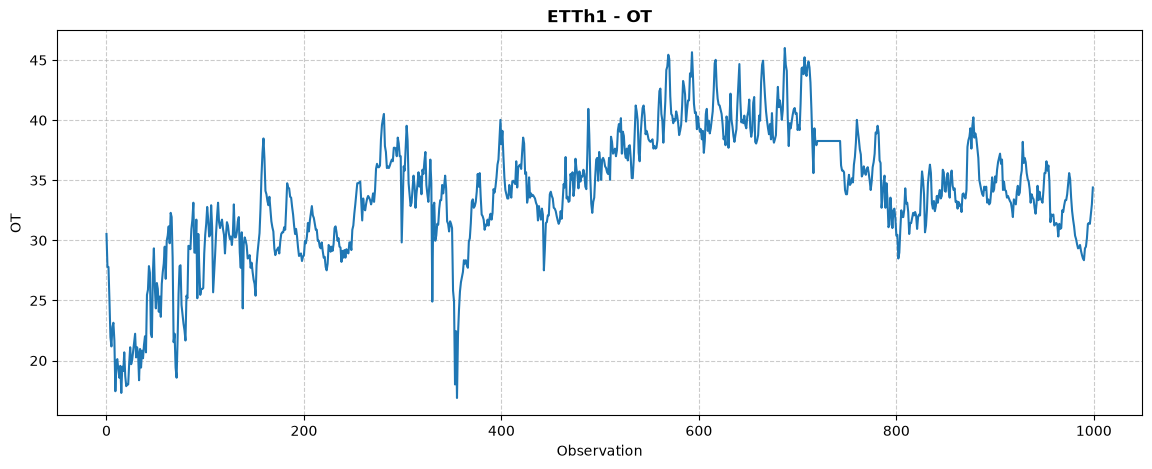

In [51]:
ETTh1 = load_dataset('ETTh1')
loading(ETTh1)

### **Weather**

In [52]:
import pandas as pd
weather_raw = pd.read_csv("../data/raw/weather/weather_raw.csv")

In [53]:
weather_raw.duplicated().sum()

1

In [54]:
weather_df = weather_raw.copy()

weather_df["date"] = pd.to_datetime(weather_df['date'])
weather_df
weather_df = weather_df.set_index('date')

In [55]:
weather_df = weather_df.drop_duplicates()
weather_df.duplicated().sum()

0

In [56]:
weather_df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 52695 entries, 2020-01-01 00:10:00 to 2021-01-01 00:00:00
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   p (mbar)              52695 non-null  float64
 1   T (degC)              52695 non-null  float64
 2   Tpot (K)              52695 non-null  float64
 3   Tdew (degC)           52695 non-null  float64
 4   rh (%)                52695 non-null  float64
 5   VPmax (mbar)          52695 non-null  float64
 6   VPact (mbar)          52695 non-null  float64
 7   VPdef (mbar)          52695 non-null  float64
 8   sh (g/kg)             52695 non-null  float64
 9   H2OC (mmol/mol)       52695 non-null  float64
 10  rho (g/m**3)          52695 non-null  float64
 11  wv (m/s)              52695 non-null  float64
 12  max. wv (m/s)         52695 non-null  float64
 13  wd (deg)              52695 non-null  float64
 14  rain (mm)             52695 non-nul

In [57]:
weather_df.to_csv("../data/raw/weather/weather.csv")

In [58]:
weather_df.duplicated().sum()

0

,p (mbar),T (degC),Tpot (K),Tdew (degC),rh (%),VPmax (mbar),VPact (mbar),VPdef (mbar),sh (g/kg),H2OC (mmol/mol),...,wv (m/s),max. wv (m/s),wd (deg),rain (mm),raining (s),SWDR (W/m�),PAR (�mol/m�/s),max. PAR (�mol/m�/s),Tlog (degC),OT
0,1008.89,0.71,273.18,-1.33,86.1,6.43,5.54,0.89,3.42,5.49,...,1.02,1.60,224.3,0.0,0.0,0.0,0.0,0.0,11.45,428.1
1,1008.76,0.75,273.22,-1.44,85.2,6.45,5.49,0.95,3.39,5.45,...,0.43,0.84,206.8,0.0,0.0,0.0,0.0,0.0,11.51,428.0
2,1008.66,0.73,273.21,-1.48,85.1,6.44,5.48,0.96,3.39,5.43,...,0.61,1.48,197.1,0.0,0.0,0.0,0.0,0.0,11.60,427.6
3,1008.64,0.37,272.86,-1.64,86.3,6.27,5.41,0.86,3.35,5.37,...,1.11,1.48,206.4,0.0,0.0,0.0,0.0,0.0,11.70,430.0
4,1008.61,0.33,272.82,-1.50,87.4,6.26,5.47,0.79,3.38,5.42,...,0.49,1.40,209.6,0.0,0.0,0.0,0.0,0.0,11.81,432.2


,p (mbar),T (degC),Tpot (K),Tdew (degC),rh (%),VPmax (mbar),VPact (mbar),VPdef (mbar),sh (g/kg),H2OC (mmol/mol),...,wv (m/s),max. wv (m/s),wd (deg),rain (mm),raining (s),SWDR (W/m�),PAR (�mol/m�/s),max. PAR (�mol/m�/s),Tlog (degC),OT
count,52695.000000,52695.000000,52695.000000,52695.000000,52695.000000,52695.000000,52695.000000,52695.000000,52695.000000,52695.000000,...,52695.000000,52695.000000,52695.000000,52695.000000,52695.000000,52695.000000,52695.000000,52695.000000,52695.000000,52695.000000
mean,989.989203,10.818476,284.797176,5.409247,72.486683,14.487217,9.676912,4.810218,6.111212,9.782426,...,1.995953,3.632844,176.849544,0.011773,25.907961,131.332703,259.865018,308.604007,21.515420,417.798081
std,9.207234,7.468546,7.616871,5.956689,19.230165,7.632931,4.023496,5.539336,2.561531,4.082675,...,43.597345,2.462475,81.195437,0.123290,111.504421,215.737068,422.790371,569.961972,7.790537,321.573043
min,955.580000,-6.440000,266.190000,-13.810000,21.160000,3.770000,2.090000,0.000000,1.300000,2.090000,...,-9999.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-9999.000000,6.900000,-9999.000000
25%,984.800000,4.590000,278.550000,0.780000,58.820000,8.480000,6.460000,1.170000,4.070000,6.530000,...,1.000000,1.770000,141.100000,0.000000,0.000000,0.000000,0.000000,0.000000,15.240000,415.500000
50%,990.920000,10.230000,284.320000,5.260000,75.400000,12.480000,8.890000,2.740000,5.610000,8.990000,...,1.770000,3.000000,195.500000,0.000000,0.000000,2.820000,9.670000,13.120000,20.440000,423.200000
75%,995.930000,16.180000,290.260000,9.700000,87.900000,18.420000,12.050000,6.440000,7.620000,12.200000,...,2.920000,4.850000,226.700000,0.000000,0.000000,182.900000,366.465000,434.290000,26.825000,437.100000
max,1020.070000,34.800000,309.130000,20.500000,100.000000,55.670000,24.160000,42.100000,15.400000,24.530000,...,13.770000,22.900000,360.000000,11.200000,600.000000,1115.290000,2131.760000,2498.940000,49.090000,524.200000



DatetimeIndex(['2020-01-01 00:10:00', '2020-01-01 00:20:00',
               '2020-01-01 00:30:00', '2020-01-01 00:40:00',
               '2020-01-01 00:50:00', '2020-01-01 01:00:00',
               '2020-01-01 01:10:00', '2020-01-01 01:20:00',
               '2020-01-01 01:30:00', '2020-01-01 01:40:00'],
              dtype='datetime64[ns]', name='date', freq=None)
date
0 days 00:10:00    52693
0 days 01:40:00        1
Name: count, dtype: int64

Available: 52695
Required: 704
Valid: True


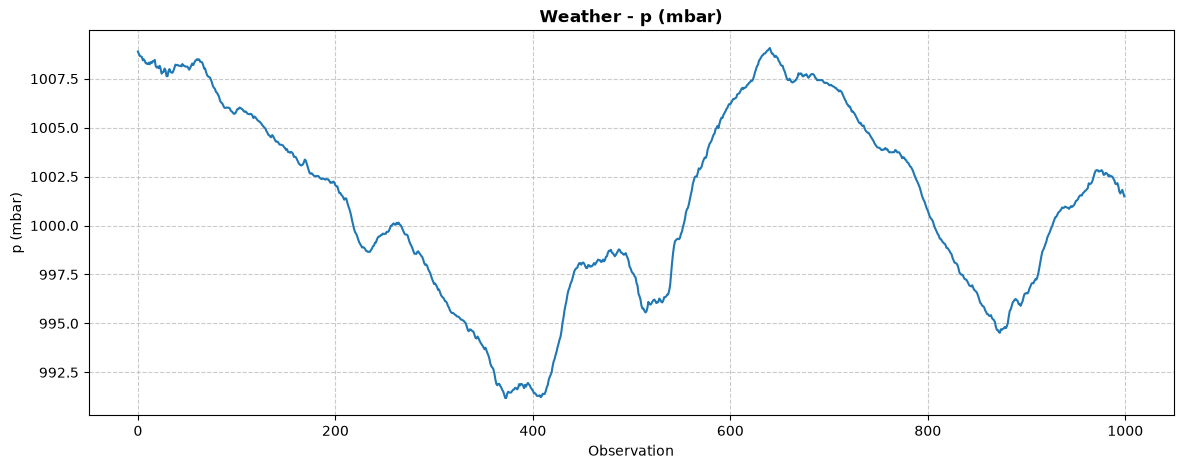

In [59]:
weather = load_dataset('Weather')
loading(weather)

### **Electricity**

,0,1,2,3,4,5,6,7,8,9,...,311,312,313,314,315,316,317,318,319,OT
0,14.0,69.0,234.0,415.0,215.0,1056.0,29.0,840.0,226.0,265.0,...,676.0,372.0,80100.0,4719.0,5002.0,48.0,38.0,1558.0,182.0,2162.0
1,18.0,92.0,312.0,556.0,292.0,1363.0,29.0,1102.0,271.0,340.0,...,805.0,452.0,95200.0,4643.0,6617.0,65.0,47.0,2177.0,253.0,2835.0
2,21.0,96.0,312.0,560.0,272.0,1240.0,29.0,1025.0,270.0,300.0,...,817.0,430.0,96600.0,4285.0,6571.0,64.0,43.0,2193.0,218.0,2764.0
3,20.0,92.0,312.0,443.0,213.0,845.0,24.0,833.0,179.0,211.0,...,801.0,291.0,94500.0,4222.0,6365.0,65.0,39.0,1315.0,195.0,2735.0
4,22.0,91.0,312.0,346.0,190.0,647.0,16.0,733.0,186.0,179.0,...,807.0,279.0,91300.0,4116.0,6298.0,75.0,40.0,1378.0,191.0,2721.0


,0,1,2,3,4,5,6,7,8,9,...,311,312,313,314,315,316,317,318,319,OT
count,26304.000000,26304.000000,26304.000000,26304.000000,26304.000000,26304.000000,26304.000000,26304.000000,26304.000000,26304.000000,...,26304.000000,26304.000000,26304.000000,26304.000000,26304.000000,26304.000000,26304.000000,26304.000000,26304.000000,26304.000000
mean,23.263762,112.885569,16.821624,440.335196,200.536724,755.035166,25.943659,1022.549270,214.867321,227.069267,...,2072.031592,1165.538853,200529.124848,10065.918491,15678.371236,350.702137,51.490344,2264.188641,507.008858,3335.883744
std,24.127164,25.553141,49.190377,152.601050,69.727348,249.598861,27.392344,231.480251,83.792517,102.182571,...,1211.430647,736.035668,146054.610575,6568.697998,9738.020500,241.241444,37.228837,545.279372,267.445473,552.754335
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,9.000000,95.000000,8.000000,334.750000,148.000000,572.000000,13.000000,840.000000,157.000000,149.000000,...,850.000000,452.000000,69300.000000,3639.000000,6456.000000,94.000000,27.000000,1999.000000,233.000000,2920.000000
50%,11.000000,113.000000,8.000000,400.000000,190.000000,725.000000,16.000000,1015.000000,194.000000,204.000000,...,1962.500000,1278.000000,174000.000000,9361.000000,13866.000000,361.000000,37.000000,2319.000000,504.000000,3271.000000
75%,24.000000,130.000000,10.000000,511.000000,239.000000,881.000000,24.000000,1169.000000,253.000000,283.000000,...,3019.000000,1726.000000,267725.000000,14719.250000,24706.000000,505.000000,57.000000,2607.000000,704.000000,3632.000000
max,140.000000,296.000000,601.000000,1170.000000,547.000000,1984.000000,178.000000,2102.000000,600.000000,752.000000,...,5749.000000,3340.000000,764000.000000,28572.000000,39728.000000,1330.000000,205.000000,4449.000000,1369.000000,6035.000000



DatetimeIndex(['2016-07-01 02:00:00', '2016-07-01 03:00:00',
               '2016-07-01 04:00:00', '2016-07-01 05:00:00',
               '2016-07-01 06:00:00', '2016-07-01 07:00:00',
               '2016-07-01 08:00:00', '2016-07-01 09:00:00',
               '2016-07-01 10:00:00', '2016-07-01 11:00:00'],
              dtype='datetime64[ns]', name='date', freq=None)
date
0 days 01:00:00    26303
Name: count, dtype: int64

Available: 26304
Required: 704
Valid: True


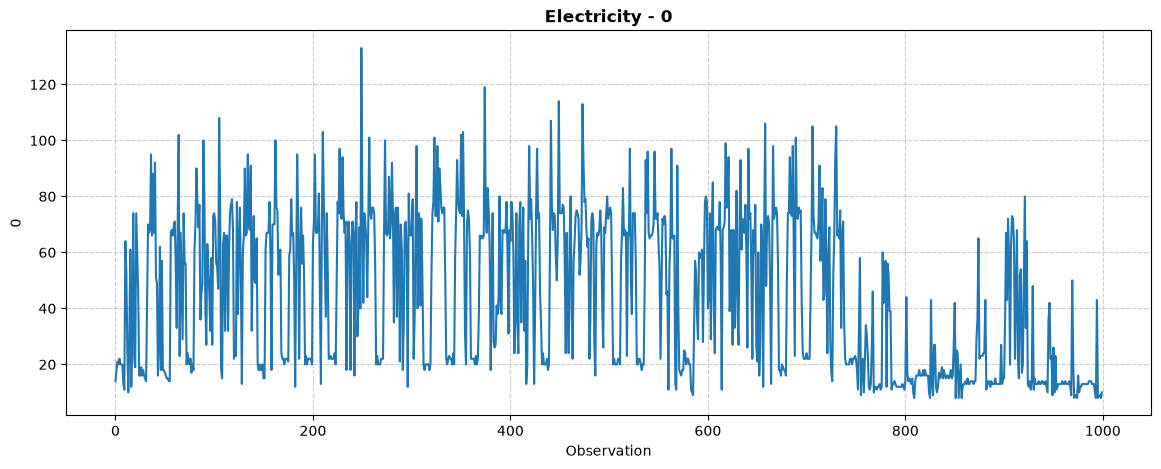

In [60]:
electricity = load_dataset("Electricity")
loading(electricity)

### **Traffic**

In [61]:
def convert_tsf_to_csv(tsf_file_path: str, output_csv_path: str):
    frequency = None
    series_data = {}
    with open(tsf_file_path, 'r', encoding='utf-8', errors='ignore') as f:
        in_data_section = False
    
        for line in f:
            line = line.strip()
            if not line or line.startswith('#'):
                continue
            
            # Extract sampling frequency from header
            if line.startswith('@frequency'):
                frequency = line.split()[1].lower()
                continue
            
            if line.startswith('@data'):
                in_data_section = True
                continue
            
            if in_data_section:
                # Each data row format: series_name:start_timestamp:v1,v2,v3,...
                parts = line.split(':')
                if len(parts) < 3:
                    continue
                
                series_name = parts[0].strip()
                
                # Fix timestamp format: "YYYY-MM-DD HH-MM-SS" -> "YYYY-MM-DD HH:MM:SS"
                raw_timestamp = parts[1].strip()
                date_part, time_part = raw_timestamp.split(' ')
                clean_timestamp = f"{date_part} {time_part.replace('-', ':')}"
                
                # Parse numeric values (replace '?' or missing values with NaN)
                raw_values = parts[2].split(',')
                values = [float(v) if v != '?' else float('nan') for v in raw_values]
                
                series_data[series_name] = {
                    'start_timestamp': clean_timestamp,
                    'values': values
                }

    # Map TSF frequency string to pandas frequency alias
    freq_map = {
        'hourly': 'h',
        'daily': 'D',
        'weekly': 'W',
        'monthly': 'MS',
        'yearly': 'YS',
        'half_hourly': '30min',
        'minutely': 'min'
    }
    pandas_freq = freq_map.get(frequency, 'h')

    # Construct the aligned DataFrame
    df_dict = {}
    for name, data in series_data.items():
        time_index = pd.date_range(
            start=data['start_timestamp'],
            periods=len(data['values']),
            freq=pandas_freq
        )
        df_dict[name] = pd.Series(data['values'], index=time_index)

    # Combine into a single wide DataFrame
    final_df = pd.DataFrame(df_dict)
    final_df.index.name = 'date'

    # Save to CSV
    final_df.to_csv(output_csv_path)
    print(f"Successfully converted '{tsf_file_path}' to '{output_csv_path}'. Shape: {final_df.shape}")
    return final_df

In [62]:
traffic_df = convert_tsf_to_csv("../data/raw/traffic/traffic_hourly_dataset.tsf", "../data/raw/traffic/traffic.csv")

Successfully converted '../data/raw/traffic/traffic_hourly_dataset.tsf' to '../data/raw/traffic/traffic.csv'. Shape: (17544, 862)


In [64]:
traffic_df.head()

,T1,T2,T3,T4,T5,T6,T7,T8,T9,T10,...,T853,T854,T855,T856,T857,T858,T859,T860,T861,T862
date,,,,,,,,,,,,,,,,,,,,,
2015-01-01 00:00:01,0.0048,0.0146,0.0289,0.0142,0.0064,0.0232,0.0162,0.0242,0.0341,0.0375,...,0.0051,0.0051,0.0074,0.0079,0.0051,0.0051,0.0339,0.0051,0.0100,0.0121
2015-01-01 01:00:01,0.0072,0.0148,0.0350,0.0174,0.0084,0.0240,0.0201,0.0338,0.0434,0.0381,...,0.0036,0.0036,0.0107,0.0058,0.0036,0.0036,0.0348,0.0036,0.0087,0.0136
2015-01-01 02:00:01,0.0040,0.0101,0.0267,0.0124,0.0049,0.0170,0.0127,0.0255,0.0332,0.0309,...,0.0030,0.0030,0.0043,0.0050,0.0030,0.0030,0.0327,0.0030,0.0061,0.0107
2015-01-01 03:00:01,0.0039,0.0060,0.0218,0.0090,0.0029,0.0118,0.0088,0.0163,0.0211,0.0199,...,0.0033,0.0033,0.0019,0.0052,0.0033,0.0033,0.0292,0.0033,0.0040,0.0071
2015-01-01 04:00:01,0.0042,0.0055,0.0191,0.0082,0.0024,0.0095,0.0064,0.0087,0.0144,0.0226,...,0.0049,0.0049,0.0011,0.0071,0.0049,0.0049,0.0264,0.0049,0.0040,0.0039


,T1,T2,T3,T4,T5,T6,T7,T8,T9,T10,...,T853,T854,T855,T856,T857,T858,T859,T860,T861,T862
0,0.0048,0.0146,0.0289,0.0142,0.0064,0.0232,0.0162,0.0242,0.0341,0.0375,...,0.0051,0.0051,0.0074,0.0079,0.0051,0.0051,0.0339,0.0051,0.0100,0.0121
1,0.0072,0.0148,0.0350,0.0174,0.0084,0.0240,0.0201,0.0338,0.0434,0.0381,...,0.0036,0.0036,0.0107,0.0058,0.0036,0.0036,0.0348,0.0036,0.0087,0.0136
2,0.0040,0.0101,0.0267,0.0124,0.0049,0.0170,0.0127,0.0255,0.0332,0.0309,...,0.0030,0.0030,0.0043,0.0050,0.0030,0.0030,0.0327,0.0030,0.0061,0.0107
3,0.0039,0.0060,0.0218,0.0090,0.0029,0.0118,0.0088,0.0163,0.0211,0.0199,...,0.0033,0.0033,0.0019,0.0052,0.0033,0.0033,0.0292,0.0033,0.0040,0.0071
4,0.0042,0.0055,0.0191,0.0082,0.0024,0.0095,0.0064,0.0087,0.0144,0.0226,...,0.0049,0.0049,0.0011,0.0071,0.0049,0.0049,0.0264,0.0049,0.0040,0.0039


,T1,T2,T3,T4,T5,T6,T7,T8,T9,T10,...,T853,T854,T855,T856,T857,T858,T859,T860,T861,T862
count,17544.000000,17544.000000,17544.000000,17544.000000,17544.000000,17544.000000,17544.000000,17544.000000,17544.000000,17544.000000,...,17544.000000,17544.000000,17544.000000,17544.000000,17544.000000,17544.000000,17544.000000,17544.000000,17544.000000,17544.000000
mean,0.049324,0.046016,0.105870,0.056633,0.026812,0.056526,0.062885,0.060598,0.062839,0.076275,...,0.017752,0.021159,0.025893,0.035347,0.023338,0.025883,0.039669,0.043058,0.029241,0.031537
std,0.062469,0.048398,0.082205,0.036746,0.035872,0.066524,0.061002,0.054689,0.043479,0.093617,...,0.013580,0.013271,0.020939,0.022303,0.014115,0.016802,0.018035,0.023567,0.017606,0.019453
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.008900,0.018100,0.035600,0.026800,0.007875,0.013900,0.020000,0.021100,0.025400,0.016600,...,0.005800,0.007900,0.006500,0.022300,0.009600,0.010700,0.027600,0.027800,0.014100,0.012500
50%,0.046300,0.036800,0.081000,0.060000,0.019000,0.041800,0.048200,0.055000,0.059500,0.055500,...,0.013900,0.021900,0.026500,0.035500,0.025900,0.028700,0.042100,0.041200,0.031800,0.034100
75%,0.059900,0.053700,0.175500,0.074700,0.024300,0.055400,0.072500,0.073700,0.081500,0.084800,...,0.030500,0.031600,0.040000,0.044000,0.033400,0.037200,0.054000,0.063800,0.039300,0.046700
max,0.474700,0.450000,0.420100,0.494700,0.406900,0.510100,0.362000,0.492500,0.366400,0.698300,...,0.122600,0.087600,0.342000,0.555500,0.288900,0.397500,0.141900,0.353200,0.415900,0.217400



DatetimeIndex(['2015-01-01 00:00:01', '2015-01-01 01:00:01',
               '2015-01-01 02:00:01', '2015-01-01 03:00:01',
               '2015-01-01 04:00:01', '2015-01-01 05:00:01',
               '2015-01-01 06:00:01', '2015-01-01 07:00:01',
               '2015-01-01 08:00:01', '2015-01-01 09:00:01'],
              dtype='datetime64[ns]', name='date', freq=None)
date
0 days 01:00:00    17543
Name: count, dtype: int64

Available: 17544
Required: 704
Valid: True


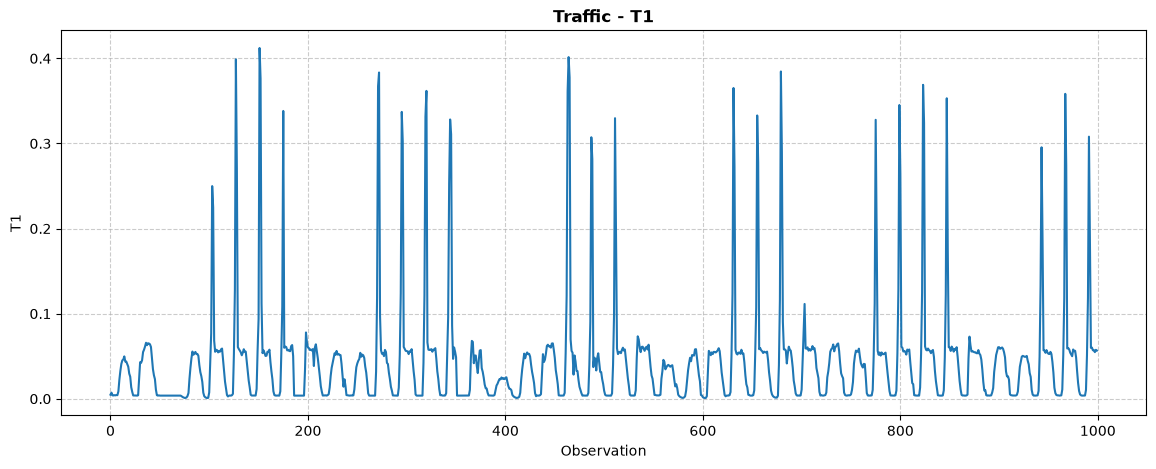

In [65]:
traffic = load_dataset("Traffic")
loading(traffic)

### **Exchange**

,0,1,2,3,4,5,6,OT
0,0.7855,1.6110,0.861698,0.634196,0.211242,0.006838,0.525486,0.5930
1,0.7818,1.6100,0.861104,0.633513,0.211242,0.006863,0.523972,0.5940
2,0.7867,1.6293,0.861030,0.648508,0.211242,0.006975,0.526316,0.5973
3,0.7860,1.6370,0.862069,0.650618,0.211242,0.006953,0.523834,0.5970
4,0.7849,1.6530,0.861995,0.656254,0.211242,0.006940,0.527426,0.5985


,0,1,2,3,4,5,6,OT
count,7588.000000,7588.000000,7588.000000,7588.000000,7588.000000,7588.000000,7588.000000,7588.000000
mean,0.776974,1.634105,0.821811,0.848146,0.142833,0.009343,0.669673,0.654418
std,0.136620,0.161544,0.117123,0.168874,0.023996,0.001458,0.082836,0.115292
min,0.483297,1.211534,0.618582,0.548617,0.109292,0.006254,0.523834,0.393153
25%,0.701422,1.532887,0.727901,0.696864,0.120814,0.008331,0.593287,0.566000
50%,0.761377,1.606574,0.811582,0.813959,0.145212,0.009151,0.662767,0.669187
75%,0.873477,1.707646,0.920394,1.014018,0.159948,0.009995,0.731835,0.734901
max,1.102536,2.109000,1.091524,1.374079,0.237954,0.013202,0.832556,0.882379



DatetimeIndex(['1990-01-01', '1990-01-02', '1990-01-03', '1990-01-04',
               '1990-01-05', '1990-01-06', '1990-01-07', '1990-01-08',
               '1990-01-09', '1990-01-10'],
              dtype='datetime64[ns]', name='date', freq=None)
date
1 days    7587
Name: count, dtype: int64

Available: 7588
Required: 704
Valid: True


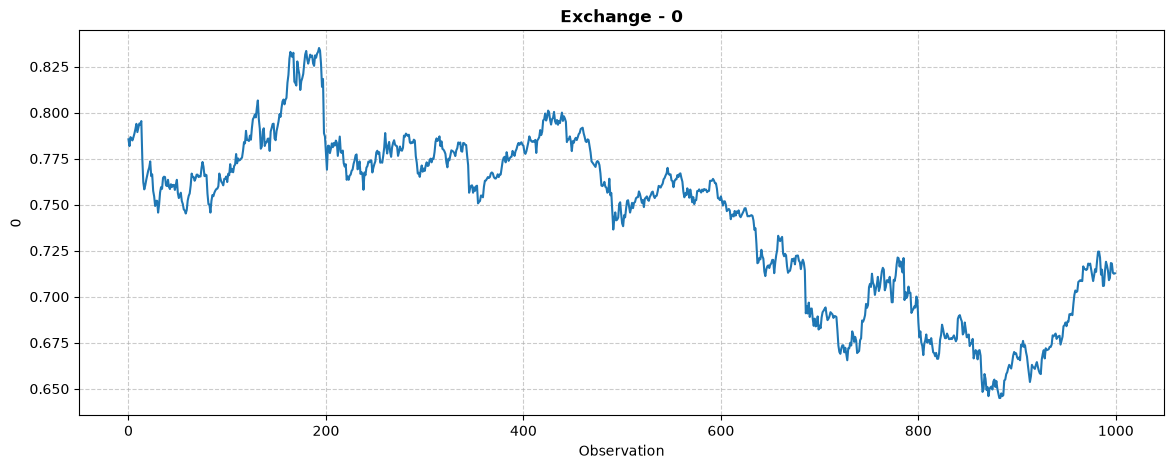

In [66]:
exchange = load_dataset("Exchange")
loading(exchange)

### **Solar**

,solar_0,solar_1,solar_2,solar_3,solar_4,solar_5,solar_6,solar_7,solar_8,solar_9,...,solar_127,solar_128,solar_129,solar_130,solar_131,solar_132,solar_133,solar_134,solar_135,solar_136
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


,solar_0,solar_1,solar_2,solar_3,solar_4,solar_5,solar_6,solar_7,solar_8,solar_9,...,solar_127,solar_128,solar_129,solar_130,solar_131,solar_132,solar_133,solar_134,solar_135,solar_136
count,52560.000000,52560.000000,52560.000000,52560.000000,52560.000000,52560.000000,52560.000000,52560.000000,52560.000000,52560.000000,...,52560.000000,52560.000000,52560.000000,52560.000000,52560.000000,52560.000000,52560.000000,52560.000000,52560.000000,52560.000000
mean,13.573475,5.989026,5.683027,6.014602,11.532876,16.024699,5.486454,5.401422,6.023158,5.649223,...,5.680850,5.980961,1.609246,4.887907,5.589557,5.659655,6.002021,5.984339,5.746928,7.909788
std,17.611179,8.652284,8.447994,8.841083,15.148663,23.617187,7.851755,7.994915,8.848634,8.415777,...,8.232889,8.772886,2.358833,7.172676,8.337873,8.424734,8.669905,8.817329,7.582154,11.716673
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,30.950000,11.450000,10.250000,11.250000,26.350000,30.000000,10.800000,10.100000,11.450000,10.250000,...,10.800000,11.300000,3.050000,9.200000,10.062500,10.250000,11.600000,11.100000,13.050000,14.600000
max,58.850000,33.350000,33.350000,33.150000,48.500000,88.900000,28.950000,29.300000,33.400000,33.000000,...,31.350000,34.400000,8.850000,26.750000,30.700000,31.950000,31.850000,33.000000,24.550000,42.950000



DatetimeIndex(['2006-01-01 00:00:00', '2006-01-01 00:10:00',
               '2006-01-01 00:20:00', '2006-01-01 00:30:00',
               '2006-01-01 00:40:00', '2006-01-01 00:50:00',
               '2006-01-01 01:00:00', '2006-01-01 01:10:00',
               '2006-01-01 01:20:00', '2006-01-01 01:30:00'],
              dtype='datetime64[ns]', freq='10T')
0 days 00:10:00    52559
Name: count, dtype: int64

Available: 52560
Required: 704
Valid: True


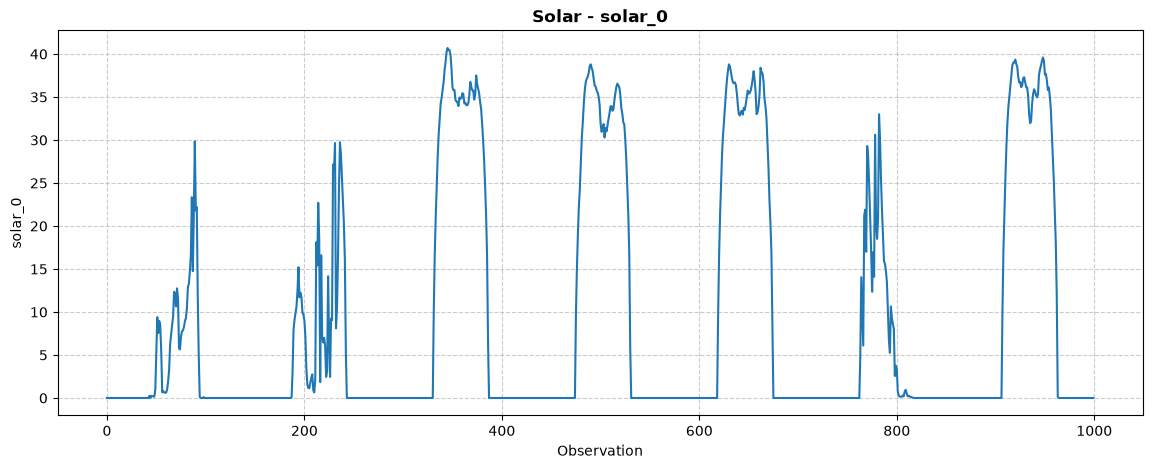

In [67]:
solar = load_dataset("Solar")
loading(solar)